In [ ]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 48.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key = "1nelF7V4AauI952qjOo0")

project = rf.workspace("study-yr0kd").project("mask-wearing-n2tjs")
version = project.version(1)
dataset = version.download("yolov8")

print(f"\nĐã tải xong! Đường dẫn file cấu hình: {dataset.location}/data.yaml")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Mask-Wearing-1 in yolov8:: 100%|██████████| 3880/3880 [00:01<00:00, 2240.04it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Đã tải xong! Đường dẫn file cấu hình: /content/Mask-Wearing-1/data.yaml


In [ ]:
%cat {dataset.location}/data.yaml

names:
- mask
- no-mask
nc: 2
roboflow:
  license: Public Domain
  project: mask-wearing-n2tjs
  url: https://universe.roboflow.com/study-yr0kd/mask-wearing-n2tjs/dataset/1
  version: 1
  workspace: study-yr0kd
test: ../test/images
train: ../train/images
val: ../valid/images


In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

result = model.train(
    data = f"{dataset.location}/data.yaml",
    epochs = 2, # Học 20 lần (mới học thì để ít cho nhanh)
    imgsz = 640, # Kích thước ảnh
    plots = True # Vẽ biểu đồ kết quả sau khi xong
)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Mask-Wearing-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

In [7]:
metrics = model.val()
print(f"Độ chính xác trung bình (mAP50): {metrics.box.map50}")

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 917.0±434.7 MB/s, size: 67.4 KB)
val: Scanning /content/Mask-Wearing-1/valid/labels.cache... 368 images, 56 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 368/368 91.3Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 23/23 3.3s/it 1:17
                   all        368        709       0.76      0.708       0.79       0.45
                  mask        182        476      0.824       0.71      0.818       0.48
               no-mask        158        233      0.696      0.707      0.762      0.419
Speed: 1.5ms preprocess, 171.2ms inference, 0.0ms loss, 23.0ms postprocess per image
Results saved to /content/runs/detect/val
Độ chính xác trung bình (mAP50): 0.7899485154528741



WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP camera connection.
WARNING ⚠️ Video stream unresponsive, please check your IP came

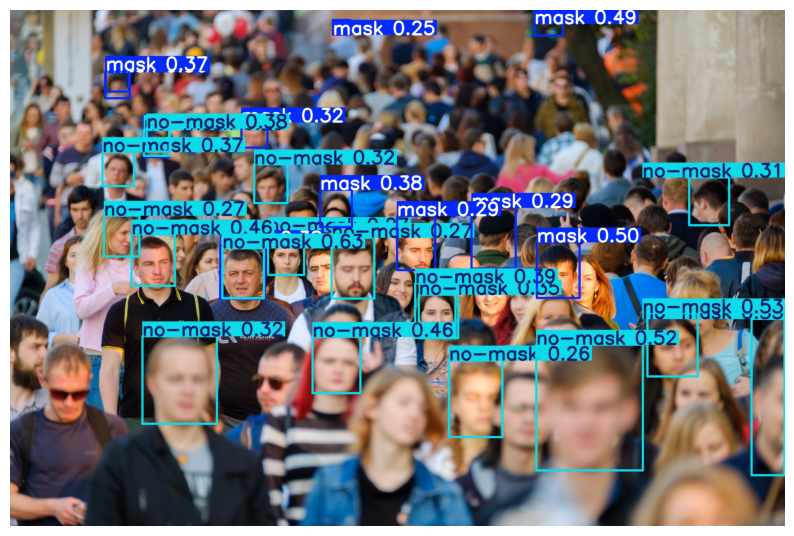

In [12]:
# Dự đoán một ảnh bất kỳ (thay link ảnh bằng ảnh bạn muốn)
results = model.predict(source='https://populationmatters.org/wp-content/uploads/2022/08/bigstock-Moscow-Russia-September-208762624_0-1-scaled.jpg', save=True)

# Hiển thị ảnh đã được khoanh vùng (bounding box)
import os
import cv2
import matplotlib.pyplot as plt

# results[0].save_dir là thư mục lưu kết quả (ví dụ: runs/detect/predict)
# results[0].path là tên file gốc (ví dụ: DSC_0078_uyojxu.jpg)
filename = os.path.basename(results[0].path)
res_path = os.path.join(results[0].save_dir, filename)

# Đọc ảnh
img = cv2.imread(res_path)

if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print(f"❌ Không tìm thấy file tại: {res_path}")